In [21]:
# 🖼 Dataset & Transforms
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 🔧 Core PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# 📈 Visualization
import matplotlib.pyplot as plt

# 🔣 Math utilities
import math

# Progress visualization utility
from tqdm import tqdm

# 🧪 Optional: If using Curvy or Hessian
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
from simplevit import SimpleViT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
# Seed everything
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [23]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomCrop(224, padding=4),
])

train_dataset = datasets.Imagenette(root='./data', split='train', transform=transform, download=False)
test_dataset = datasets.Imagenette(root='./data', split='val', transform=transform, download=False)

# train_x = torch.stack([x[0] for x in train_dataset])
# train_y = torch.tensor([x[1] for x in train_dataset])

In [24]:
def create_data_loaders(train_dataset, test_dataset, batch_size):
    """Create data loaders for training and testing"""
    g = torch.Generator().manual_seed(42)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=16,
        pin_memory=True,
        generator=g
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=16,
        pin_memory=True,
        generator=g
    )
    return train_loader, test_loader

In [25]:
train_loader, test_loader = create_data_loaders(
        train_dataset, 
        test_dataset, 
        64
    )

In [26]:
from torch.optim import optimizer
lrs = [1e-2, 1e-3, 1e-4, 1e-5]
num_epochs = 20

In [27]:
all_train_losses = []
all_test_losses = []
all_train_accuracies = []
all_test_accuracies = []

In [28]:
from tqdm import tqdm

for lr in lrs:
    model = SimpleViT(image_size=224, patch_size=16, num_classes=10)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        # Training phase with batch-level progress bar
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_bar = tqdm(train_loader, desc=f'Train LR={lr}, Epoch={epoch+1}/{num_epochs}', leave=False)
        for data, target in train_bar:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = output.max(1)
            train_total += target.size(0)
            train_correct += predicted.eq(target).sum().item()
            
            # Update progress bar postfix with loss and accuracy so far
            train_bar.set_postfix(loss=train_loss / (train_total / data.size(0)),
                                  acc=100. * train_correct / train_total)
        
        train_loss /= len(train_loader)
        train_accuracy = 100.0 * train_correct / train_total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Testing phase with batch-level progress bar
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        test_bar = tqdm(test_loader, desc=f'Test LR={lr}, Epoch={epoch+1}/{num_epochs}', leave=False)
        with torch.no_grad():
            for data, target in test_bar:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                test_loss += loss.item()
                _, predicted = output.max(1)
                test_total += target.size(0)
                test_correct += predicted.eq(target).sum().item()
                
                test_bar.set_postfix(loss=test_loss / (test_total / data.size(0)),
                                     acc=100. * test_correct / test_total)

        test_loss /= len(test_loader)
        test_accuracy = 100.0 * test_correct / test_total
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)
        
        print(f'LR: {lr}, Epoch: {epoch+1}/{num_epochs}, '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')

    all_train_losses.append(train_losses)
    all_test_losses.append(test_losses)
    all_train_accuracies.append(train_accuracies)
    all_test_accuracies.append(test_accuracies)

Train LR=0.01, Epoch=1/20:   0%|          | 0/148 [00:00<?, ?it/s]

LR: 0.01, Epoch: 1/20, Train Loss: 2.4841, Train Acc: 9.95%, Test Loss: 2.3446, Test Acc: 9.91%


LR: 0.01, Epoch: 2/20, Train Loss: 2.3134, Train Acc: 10.04%, Test Loss: 2.3075, Test Acc: 10.04%


LR: 0.01, Epoch: 3/20, Train Loss: 2.3056, Train Acc: 9.95%, Test Loss: 2.3051, Test Acc: 10.06%


LR: 0.01, Epoch: 4/20, Train Loss: 2.3046, Train Acc: 10.53%, Test Loss: 2.3068, Test Acc: 9.86%


...

LR: 1e-05, Epoch: 16/20, Train Loss: 1.3713, Train Acc: 54.42%, Test Loss: 1.3947, Test Acc: 54.01%


LR: 1e-05, Epoch: 17/20, Train Loss: 1.3420, Train Acc: 55.29%, Test Loss: 1.4030, Test Acc: 52.82%


LR: 1e-05, Epoch: 18/20, Train Loss: 1.3144, Train Acc: 56.49%, Test Loss: 1.3488, Test Acc: 55.21%


LR: 1e-05, Epoch: 19/20, Train Loss: 1.2839, Train Acc: 57.38%, Test Loss: 1.3412, Test Acc: 55.82%


LR: 1e-05, Epoch: 20/20, Train Loss: 1.2600, Train Acc: 58.19%, Test Loss: 1.3160, Test Acc: 56.33%


In [29]:
print(f"Number of parameters in model: {sum(p.numel() for p in model.parameters())}")


Number of parameters in model: 2308618


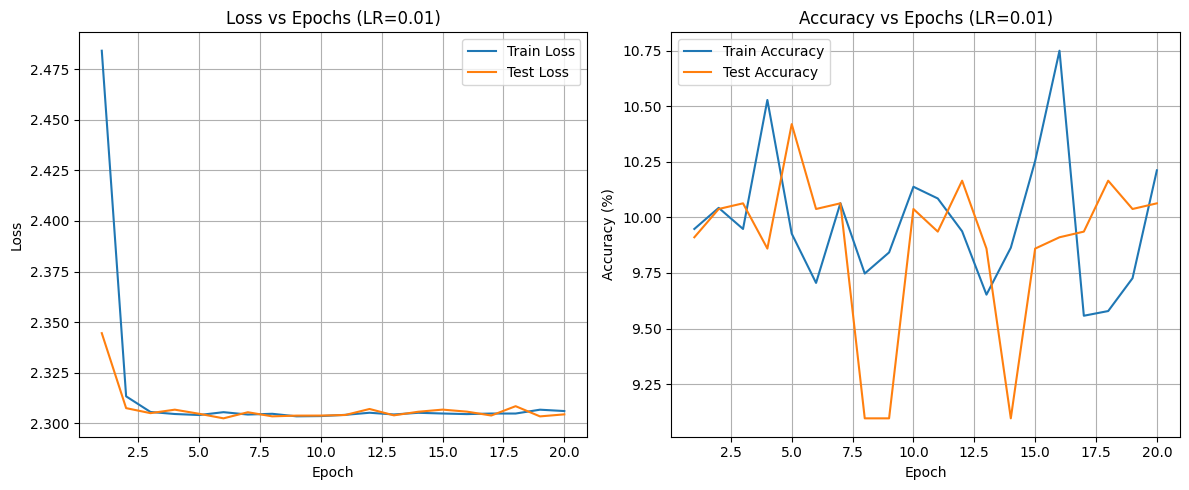

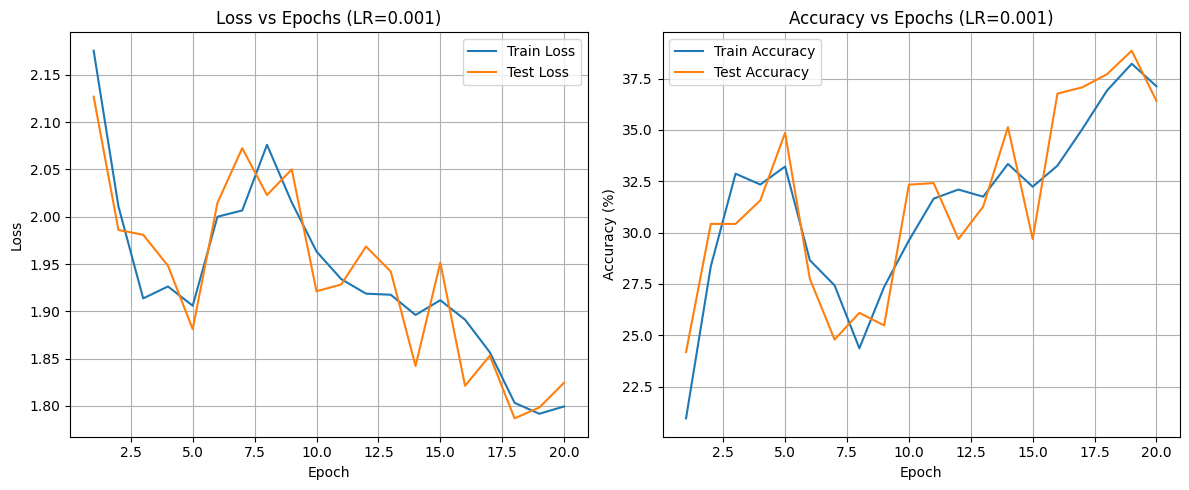

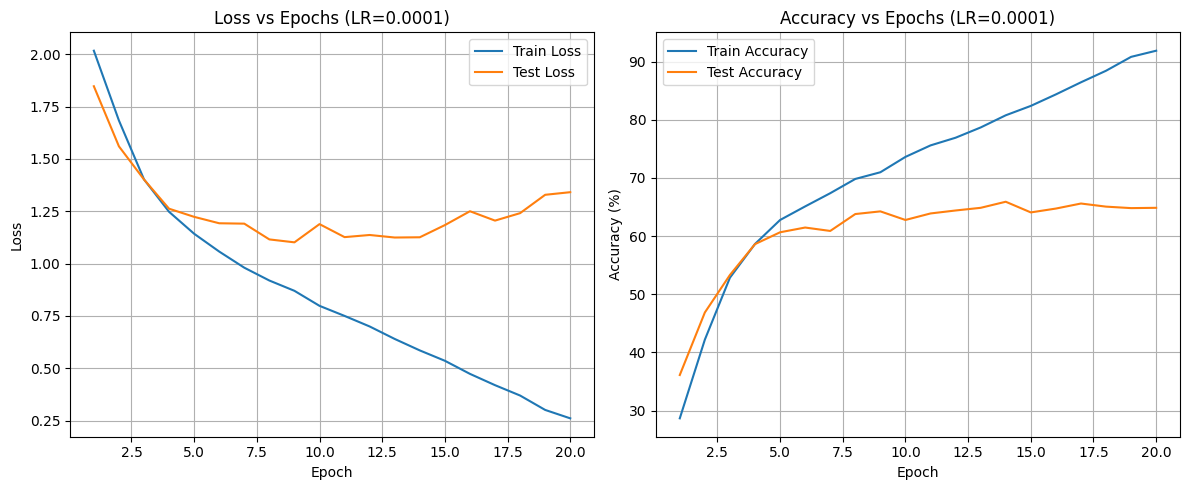

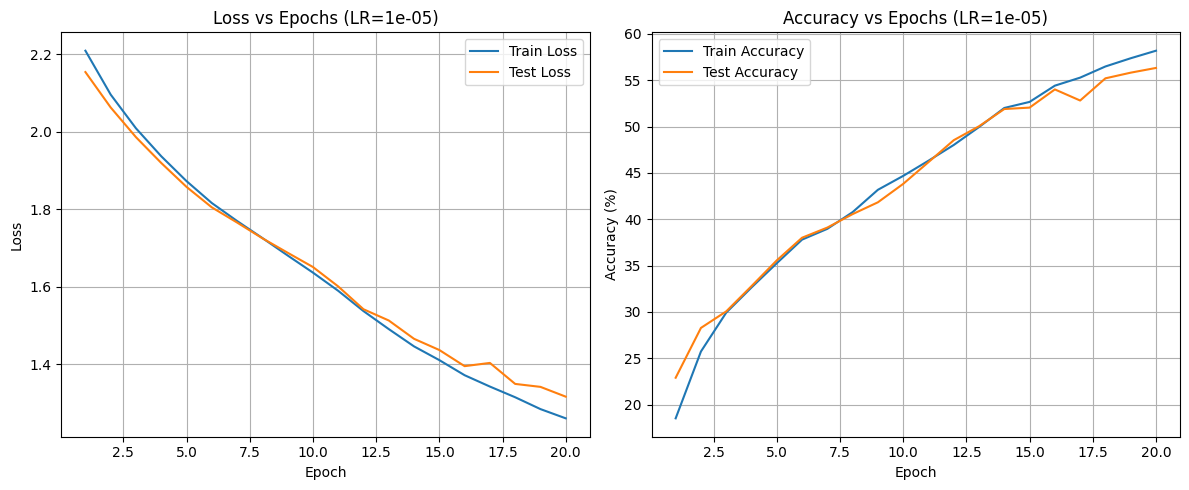

In [30]:
import matplotlib.pyplot as plt

for i, lr in enumerate(lrs):
    epochs = range(1, num_epochs + 1)
    
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, all_train_losses[i], label='Train Loss')
    plt.plot(epochs, all_test_losses[i], label='Test Loss')
    plt.title(f'Loss vs Epochs (LR={lr})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, all_train_accuracies[i], label='Train Accuracy')
    plt.plot(epochs, all_test_accuracies[i], label='Test Accuracy')
    plt.title(f'Accuracy vs Epochs (LR={lr})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [35]:
best_lr_index = max(range(len(all_test_accuracies)), key=lambda i: max(all_test_accuracies[i]))
best_epoch_index = max(range(len(all_test_accuracies[best_lr_index])), key=lambda i: all_test_accuracies[best_lr_index][i])
print(f"Best learning rate: {lrs[best_lr_index]} with max test accuracy: {max(all_test_accuracies[best_lr_index])} at epoch {best_epoch_index}")
best_loss = min(all_test_losses[best_lr_index])
print(f"Best test loss: {best_loss} at epoch {best_epoch_index}")

Best learning rate: 0.0001 with max test accuracy: 65.91082802547771 at epoch 13
Best test loss: 1.1012355084380796 at epoch 13


In [ ]:
new_all_train_losses = all_train_losses
new_all_test_losses = all_test_losses
new_all_train_accuracies = all_train_accuracies
new_all_test_accuracies = all_test_accuracies

In [ ]:
from tqdm import tqdm

for lr in lrs:
    model = SimpleViT(image_size=224, patch_size=16, num_classes=10)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        # Training phase with batch-level progress bar
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_bar = tqdm(train_loader, desc=f'Train LR={lr}, Epoch={epoch+1}/{num_epochs}', leave=False)
        for data, target in train_bar:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = output.max(1)
            train_total += target.size(0)
            train_correct += predicted.eq(target).sum().item()
            
            # Update progress bar postfix with loss and accuracy so far
            train_bar.set_postfix(loss=train_loss / (train_total / data.size(0)),
                                  acc=100. * train_correct / train_total)
        
        train_loss /= len(train_loader)
        train_accuracy = 100.0 * train_correct / train_total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Testing phase with batch-level progress bar
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        test_bar = tqdm(test_loader, desc=f'Test LR={lr}, Epoch={epoch+1}/{num_epochs}', leave=False)
        with torch.no_grad():
            for data, target in test_bar:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                test_loss += loss.item()
                _, predicted = output.max(1)
                test_total += target.size(0)
                test_correct += predicted.eq(target).sum().item()
                
                test_bar.set_postfix(loss=test_loss / (test_total / data.size(0)),
                                     acc=100. * test_correct / test_total)

        test_loss /= len(test_loader)
        test_accuracy = 100.0 * test_correct / test_total
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)
        
        print(f'LR: {lr}, Epoch: {epoch+1}/{num_epochs}, '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')

    all_train_losses.append(train_losses)
    all_test_losses.append(test_losses)
    all_train_accuracies.append(train_accuracies)
    all_test_accuracies.append(test_accuracies)